In [1]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/clean_nav_history.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [2]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [3]:
nav.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

print("Saved")

Saved


In [4]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund]

    start_nav = df["nav"].iloc[0]
    end_nav = df["nav"].iloc[-1]

    years = len(df) / 252

    cagr = ((end_nav/start_nav)**(1/years)-1)*100

    cagr_results.append([fund,cagr])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code","cagr_pct"]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.541248
1,100025,4.294835
2,100033,28.899384
3,101206,22.604787
4,101207,7.643258


In [5]:
cagr_df.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

In [6]:
rf = 0.065

sharpe_list = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund]

    mean_return = df["daily_return"].mean()*252

    volatility = (
        df["daily_return"].std()
        * np.sqrt(252)
    )

    sharpe = (
        (mean_return-rf)
        / volatility
    )

    sharpe_list.append([fund,sharpe])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code","sharpe_ratio"]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [7]:
sharpe_df.to_csv(
    "../data/processed/sharpe_values.csv",
    index=False
)

In [8]:
sortino_list = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund]

    mean_return = (
        df["daily_return"].mean()*252
    )

    downside = df[
        df["daily_return"] < 0
    ]["daily_return"]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    sortino = (
        (mean_return-rf)
        / downside_std
    )

    sortino_list.append(
        [fund,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code","sortino_ratio"]
)

sortino_df.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)

In [9]:
drawdown_results = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"]==fund
    ].copy()

    rolling_max = (
        df["nav"].cummax()
    )

    drawdown = (
        df["nav"]/rolling_max
    ) - 1

    max_dd = drawdown.min()

    drawdown_results.append(
        [fund,max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

In [10]:
nifty = benchmark[
    benchmark["index_name"]=="NIFTY50"
].copy()

nifty["benchmark_return"] = (
    nifty["close_value"]
    .pct_change()
)

alpha_beta = []

for fund in nav["amfi_code"].unique():

    f = nav[
        nav["amfi_code"]==fund
    ][["date","daily_return"]]

    merged = pd.merge(
        f,
        nifty[[
            "date",
            "benchmark_return"
        ]],
        on="date"
    )

    merged = merged.dropna()

    slope, intercept, r, p, std = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta.append([
        fund,
        intercept*252,
        slope
    ])

alpha_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [11]:
scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(alpha_df)
    .merge(drawdown_df)
)

scorecard["score"] = (
    scorecard["cagr_pct"].rank(pct=True)*30
    + scorecard["sharpe_ratio"].rank(pct=True)*25
    + scorecard["alpha"].rank(pct=True)*20
    + scorecard["max_drawdown"].rank(
        pct=True,
        ascending=False
      )*25
)

scorecard = scorecard.sort_values(
    "score",
    ascending=False
)

scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

scorecard.head()

,amfi_code,cagr_pct,sharpe_ratio,alpha,beta,max_drawdown,score
39,149324,30.965766,0.949796,0.298179,0.132608,-0.311719,88.625
21,119598,31.095664,0.945308,0.301114,0.074266,-0.287060,88.625
25,120505,31.481115,1.180101,0.293014,-0.017391,-0.181885,87.125
36,148569,30.643215,1.234930,0.283473,-0.010201,-0.163967,83.125
38,149323,28.381646,1.132122,0.265836,0.003479,-0.172481,76.875


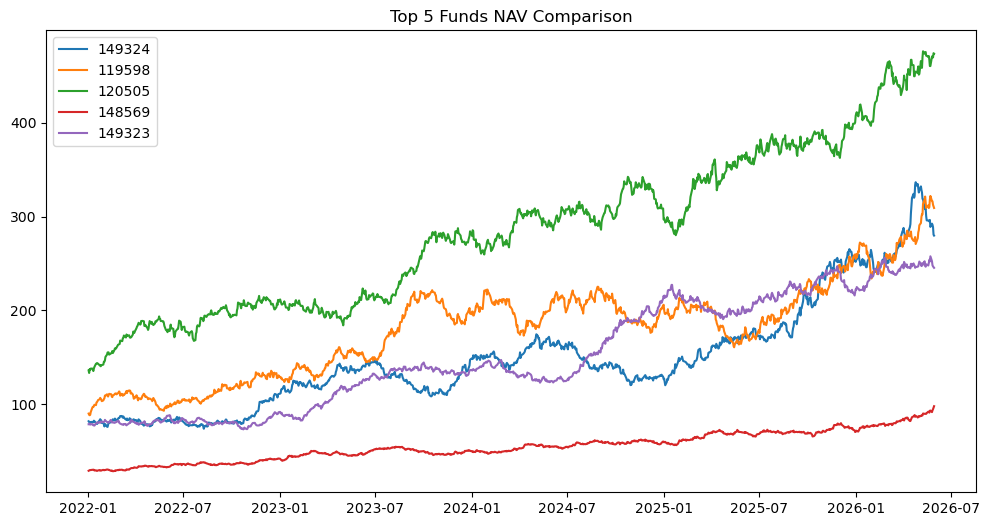

In [12]:
top_funds = scorecard.head(5)["amfi_code"]

plt.figure(figsize=(12,6))

for fund in top_funds:

    df = nav[
        nav["amfi_code"]==fund
    ]

    plt.plot(
        df["date"],
        df["nav"],
        label=str(fund)
    )

plt.legend()
plt.title("Top 5 Funds NAV Comparison")
plt.savefig(
    "../reports/benchmark_chart.png"
)

plt.show()